## Diabetes Predictions

# Problem Statement

The goal of this project is to predict diabetes disease progression based on
patient health features using a Decision Tree Regressor.

In [41]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
from sklearn.datasets import load_diabetes

In [43]:
dataset=load_diabetes()

# Dataset

The dataset is the Diabetes dataset available in Scikit-Learn.

Features:
- age
- sex
- bmi
- bp
- s1
- s2
- s3
- s4
- s5
- s6

Target:
Disease progression score

In [44]:
# Real values ke liye unscaled dataset load karo
from sklearn.datasets import load_diabetes
import numpy as np

dataset_raw = load_diabetes(scaled=False)   # Real values wala
dataset_scaled = load_diabetes(scaled=True) # Scaled values wala (model ke liye)

n = dataset_raw.data.shape[0]  # 442 patients

# Har feature ka mean aur scale factor nikalo
# Sklearn formula: scaled = (real - mean) / (std * sqrt(n))
means = dataset_raw.data.mean(axis=0)
scale_factors = dataset_raw.data.std(axis=0) * np.sqrt(n)

print("Conversion ready! Real → Scaled formula set ho gaya.")
print(f"Features: {dataset_raw.feature_names}")

Conversion ready! Real → Scaled formula set ho gaya.
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [45]:
dataset

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [46]:
print(dataset['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [47]:
dataset

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [48]:
import pandas as pd
df_diabetes=pd.DataFrame(dataset.data,columns=['age',
  'sex',
  'bmi',
  'bp',
  's1',
  's2',
  's3',
  's4',
  's5',
  's6'])
df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [49]:
df_diabetes.shape

(442, 10)

In [50]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [51]:
df_diabetes.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [52]:
## Independent and dependent features
X=df_diabetes
y=dataset['target']

The dataset is divided into training and testing sets.
80% is used for training and 20% for testing.

In [53]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=10)

In [54]:
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207
389,-0.005515,0.050680,0.001339,-0.084856,-0.011201,-0.016658,0.048640,-0.039493,-0.041176,-0.088062
121,0.063504,-0.044642,0.017506,0.021872,0.008063,0.021546,-0.036038,0.034309,0.019907,0.011349
195,0.027178,0.050680,0.025051,0.014987,0.025950,0.048477,-0.039719,0.034309,0.007838,0.023775
69,0.016281,-0.044642,-0.046085,-0.005670,-0.075870,-0.061438,-0.013948,-0.039493,-0.051404,0.019633


In [55]:
## correlation
X_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.197408,0.198359,0.394903,0.238375,0.192920,-0.128403,0.227110,0.314151,0.351570
sex,0.197408,1.000000,0.108261,0.221914,0.057674,0.180315,-0.379464,0.324882,0.150956,0.193322
bmi,0.198359,0.108261,1.000000,0.356324,0.226047,0.248146,-0.395021,0.412826,0.435505,0.358273
bp,0.394903,0.221914,0.356324,1.000000,0.238295,0.165632,-0.192505,0.249141,0.420236,0.368882
s1,0.238375,0.057674,0.226047,0.238295,1.000000,0.872781,0.006313,0.559626,0.566312,0.356280
s2,0.192920,0.180315,0.248146,0.165632,0.872781,1.000000,-0.265114,0.684840,0.325759,0.315890
s3,-0.128403,-0.379464,-0.395021,-0.192505,0.006313,-0.265114,1.000000,-0.754616,-0.370523,-0.297055
s4,0.227110,0.324882,0.412826,0.249141,0.559626,0.684840,-0.754616,1.000000,0.609983,0.436311
s5,0.314151,0.150956,0.435505,0.420236,0.566312,0.325759,-0.370523,0.609983,1.000000,0.490970
s6,0.351570,0.193322,0.358273,0.368882,0.356280,0.315890,-0.297055,0.436311,0.490970,1.000000


<Axes: >

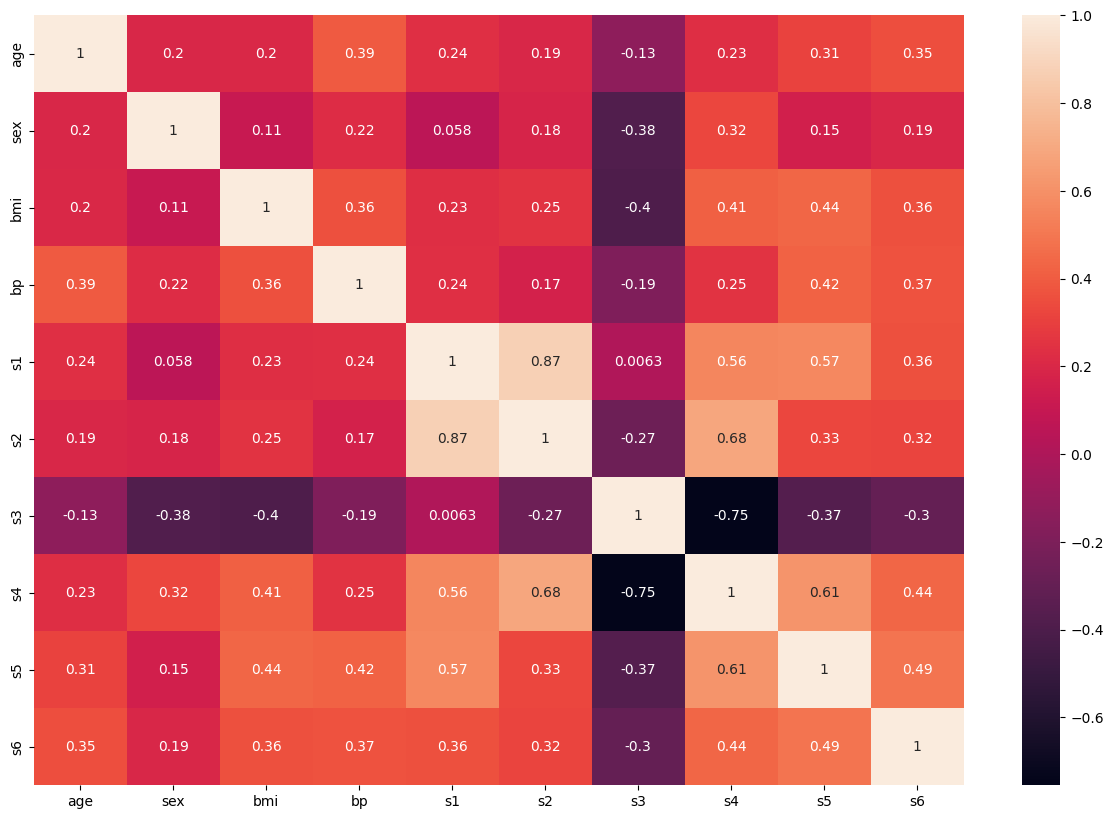

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)

In [57]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()
regressor.fit(X_train,y_train)

DecisionTreeRegressor()

## Hyperparameter Tuning

GridSearchCV is used to find the best combination of hyperparameters.

In [58]:
param={
    'criterion':['squared_error','friedman_mse','absolute_error'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,10,15,20,25],
    'max_features':['auto','sqrt','log2']
}

In [59]:
param

{'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
 'max_features': ['auto', 'sqrt', 'log2']}

In [60]:
from sklearn.model_selection import GridSearchCV

In [61]:
regressor=DecisionTreeRegressor()

In [62]:
grid=GridSearchCV(regressor,param_grid=param,cv=5,scoring='neg_mean_squared_error')

In [63]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [64]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 4,
 'max_features': 'sqrt',
 'splitter': 'random'}

In [65]:
## predictions
y_pred=grid.predict(X_test)

In [66]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [67]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.2602170078606363
55.023793249357155
4681.1034559556565


In [68]:
selectedmodel=DecisionTreeRegressor(criterion='friedman_mse',max_depth=4,max_features='log2',splitter='random')

In [69]:
selectedmodel.fit(X_train,y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=4,
                      max_features='log2', splitter='random')

[Text(0.5446428571428571, 0.9, 'x[3] <= 0.015\nfriedman_mse = 5757.456\nsamples = 309\nvalue = 152.738'),
 Text(0.2857142857142857, 0.7, 'x[7] <= 0.065\nfriedman_mse = 4429.114\nsamples = 196\nvalue = 131.092'),
 Text(0.4151785714285714, 0.8, 'True  '),
 Text(0.14285714285714285, 0.5, 'x[2] <= -0.011\nfriedman_mse = 3960.65\nsamples = 174\nvalue = 125.069'),
 Text(0.07142857142857142, 0.3, 'x[8] <= -0.002\nfriedman_mse = 2164.411\nsamples = 106\nvalue = 106.151'),
 Text(0.03571428571428571, 0.1, 'friedman_mse = 1750.997\nsamples = 82\nvalue = 98.598'),
 Text(0.10714285714285714, 0.1, 'friedman_mse = 2715.957\nsamples = 24\nvalue = 131.958'),
 Text(0.21428571428571427, 0.3, 'x[9] <= 0.082\nfriedman_mse = 5333.129\nsamples = 68\nvalue = 154.559'),
 Text(0.17857142857142858, 0.1, 'friedman_mse = 4936.297\nsamples = 64\nvalue = 148.625'),
 Text(0.25, 0.1, 'friedman_mse = 2105.25\nsamples = 4\nvalue = 249.5'),
 Text(0.42857142857142855, 0.5, 'x[0] <= -0.069\nfriedman_mse = 5578.198\nsamples

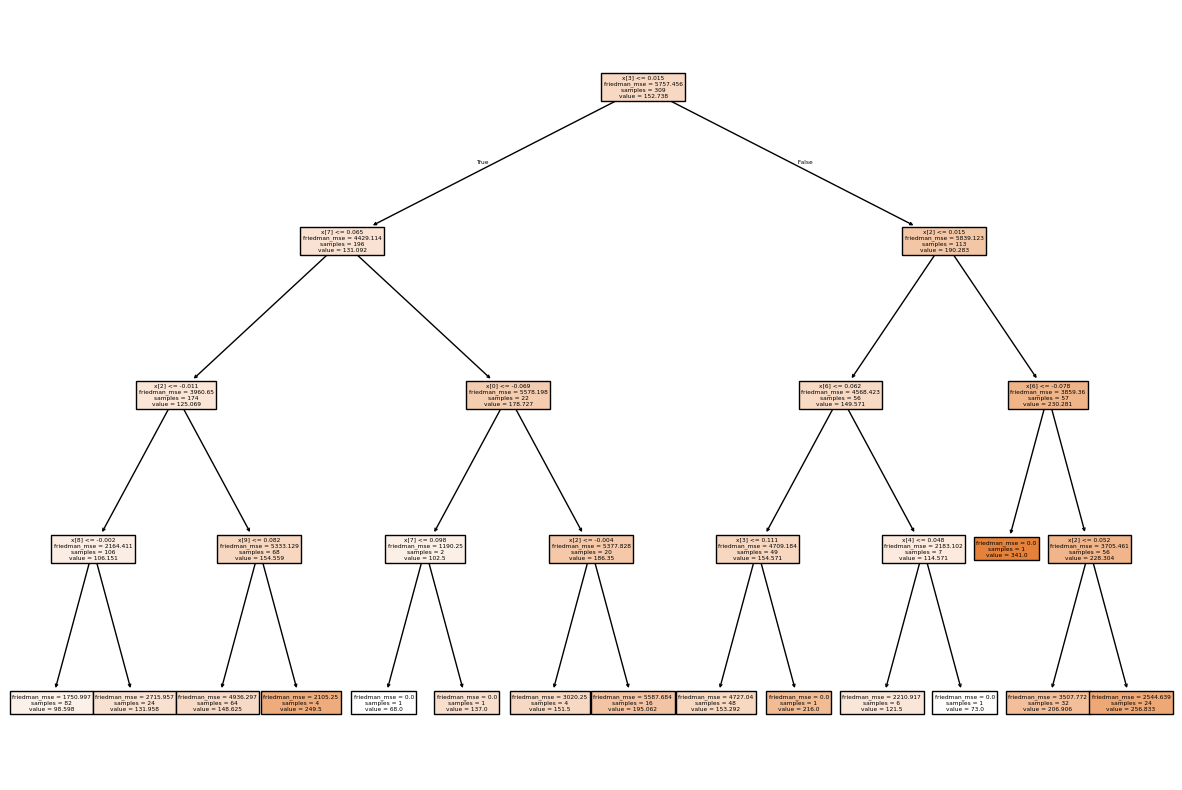

In [70]:
##Visualize the Decision Tree
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(selectedmodel,filled=True)

In [71]:
# ============================================================
# USER INPUT — Real values enter karo (standardized nahi!)
# ============================================================

print("=" * 55)
print("   DIABETES PROGRESSION PREDICTOR")
print("=" * 55)

real_age  = float(input("Age (years)            [19–79]  : "))
real_sex  = float(input("Sex (1=Male, 2=Female) [1 or 2] : "))
real_bmi  = float(input("BMI                    [18–42]  : "))
real_bp   = float(input("Blood Pressure (avg)   [62–133] : "))
real_s1   = float(input("S1 - Total Cholesterol [97–301] : "))
real_s2   = float(input("S2 - LDL               [42–242] : "))
real_s3   = float(input("S3 - HDL               [22–99]  : "))
real_s4   = float(input("S4 - TCH ratio         [2–9]    : "))
real_s5   = float(input("S5 - Triglycerides log [3.3–6.1]: "))
real_s6   = float(input("S6 - Blood Sugar       [58–124] : "))

# ============================================================
# Automatic conversion: Real → Scaled (model ke liye)
# ============================================================

real_values   = np.array([real_age, real_sex, real_bmi, real_bp,
                           real_s1,  real_s2,  real_s3,  real_s4,
                           real_s5,  real_s6])

scaled_values = (real_values - means) / scale_factors  # ← yehi magic line hai

# Predict
prediction = selectedmodel.predict(scaled_values.reshape(1, -1))

print("\n" + "=" * 55)
print(f"  Predicted Disease Progression Score : {prediction[0]:.1f}")
print("=" * 55)
print("  (Score range: ~25 to ~346)")
print("  Low < 100  |  Medium 100–200  |  High > 200")
print("=" * 55)

   DIABETES PROGRESSION PREDICTOR
Age (years)            [19–79]  : 89
Sex (1=Male, 2=Female) [1 or 2] : 2
BMI                    [18–42]  : 54
Blood Pressure (avg)   [62–133] : 78
S1 - Total Cholesterol [97–301] : 100
S2 - LDL               [42–242] : 55
S3 - HDL               [22–99]  : 55
S4 - TCH ratio         [2–9]    : 5
S5 - Triglycerides log [3.3–6.1]: 5
S6 - Blood Sugar       [58–124] : 56

  Predicted Disease Progression Score : 148.6
  (Score range: ~25 to ~346)
  Low < 100  |  Medium 100–200  |  High > 200


# Conclusion

The Decision Tree Regressor successfully predicted diabetes progression scores.

The model achieved an R² score of X.

Further improvements can be made using Random Forest and XGBoost.

In [72]:
import pickle

model_path = "/content/drive/MyDrive/👩‍💻Deep learning mam/learnmachine/learnmachine/10-Decision Tree/Project/model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(selectedmodel, f)

print("Model saved")

Model saved


In [73]:
import os

os.path.exists("/content/drive/MyDrive/👩‍💻Deep learning mam/learnmachine/learnmachine/10-Decision Tree/Project/model.pkl")

True